# Use Case: <font color="#C70039">Interpretable Machine Learning with LIME for tabular data</font>
* Course: AML
* Lecturer: <a href="https://www.gernotheisenberg.de/">Gernot Heisenberg</a>
* Author of notebook: <a href="https://www.gernotheisenberg.de/">Gernot Heisenberg</a>
* Date:   06.01.2026
* Matriculation number: 11147022
* Student: Tim Köhne

<img src="https://miro.medium.com/max/664/1*J1V-RIBHIcX-Aej0x7UXnA.png" style="float: center;" width="600">

---------------------------------

### Description 
This is one implementation example for LIME interpreting a random forest ensemble model that predicts tabular data. 
Please try to understand the implementation.

---------------------------------

### Imports
Import all necessary python utilities for loading, preprocessing and predicting the data. 

### <font color="FF0000">TASKS</font>
Try out other tabular data sets (e.g. stroke data set).

In [25]:
# Import necessary libraries
import pandas as pd
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from lime import lime_tabular

%matplotlib inline

### Load and preprocess the data

In [26]:
# Load dataset
iris = load_iris()
df = pd.DataFrame(iris.data, columns=iris.feature_names)
df['target'] = iris.target

# Prepare data
X = df.drop('target', axis=1)
y = df['target']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

### Set up the model and train

In [27]:
# Train Random Forest model
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train_scaled, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


### Create LIME tabular explainer

[('petal width (cm) <= -1.18', -0.20498626466800568), ('-1.28 < petal length (cm) <= 0.30', 0.1929524233101131), ('sepal length (cm) <= -0.86', -0.03847629749697822), ('-0.14 < sepal width (cm) <= 0.76', 0.02721843344452947)]


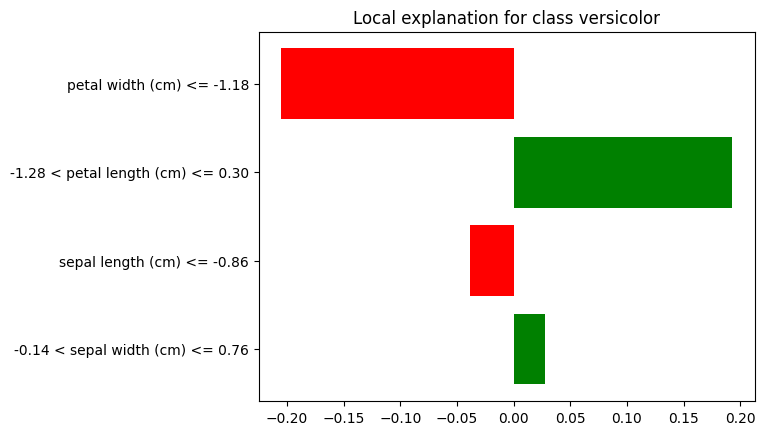

In [28]:
explainer = lime_tabular.LimeTabularExplainer(
    X_train_scaled,
    feature_names=X.columns,
    class_names=iris.target_names,
    mode='classification'
)

# Choose an instance to explain
instance = X_test_scaled[20]

# Generate explanation
exp = explainer.explain_instance(instance, rf_model.predict_proba, num_features=4)

# Visualize explanation
exp.as_pyplot_figure()

# Print feature importance
print(exp.as_list())

In [29]:
import pandas as pd
import numpy as np
import sklearn
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score
from sklearn.preprocessing import LabelEncoder
from sklearn.impute import SimpleImputer
import lime
import lime.lime_tabular
import matplotlib.pyplot as plt

%matplotlib inline

## 1. Data Loading and Preprocessing

In [30]:
data_path = 'data/healthcare-dataset-stroke-data.csv'
print(f"Loading data from {data_path}...")
df = pd.read_csv(data_path)

if 'id' in df.columns:
    df = df.drop(columns=['id'])

# Handle missing BMI values
df['bmi'] = pd.to_numeric(df['bmi'], errors='coerce')
imputer = SimpleImputer(strategy='median')
df['bmi'] = imputer.fit_transform(df[['bmi']])

print("Columns:", df.columns.tolist())
print(df.info())

Loading data from data/healthcare-dataset-stroke-data.csv...
Columns: ['gender', 'age', 'hypertension', 'heart_disease', 'ever_married', 'work_type', 'Residence_type', 'avg_glucose_level', 'bmi', 'smoking_status', 'stroke']
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5110 entries, 0 to 5109
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   gender             5110 non-null   object 
 1   age                5110 non-null   float64
 2   hypertension       5110 non-null   int64  
 3   heart_disease      5110 non-null   int64  
 4   ever_married       5110 non-null   object 
 5   work_type          5110 non-null   object 
 6   Residence_type     5110 non-null   object 
 7   avg_glucose_level  5110 non-null   float64
 8   bmi                5110 non-null   float64
 9   smoking_status     5110 non-null   object 
 10  stroke             5110 non-null   int64  
dtypes: float64(3), int64(3), object(5)
memor

In [31]:
# Encode categorical variables
categorical_features = ['gender', 'ever_married', 'work_type', 'Residence_type', 'smoking_status']
categorical_names = {}
label_encoders = {}

for feature in categorical_features:
    le = LabelEncoder()
    df[feature] = le.fit_transform(df[feature].astype(str))
    label_encoders[feature] = le
    categorical_names[feature] = le.classes_
    
categorical_features_indices = [df.columns.get_loc(c) for c in categorical_features]

# Prepare Features and Target
target_col = 'stroke'
X = df.drop(columns=[target_col])
y = df[target_col]
feature_names = X.columns.tolist()

# Split Data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("\nX_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)


X_train shape: (4088, 10)
X_test shape: (1022, 10)


## 2. Model Training
We train a Random Forest Classifier with balanced class weights to handle the dataset imbalance.

In [32]:
print("\nTraining RandomForestClassifier with balanced class weights...")
rf = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')
rf.fit(X_train, y_train)

y_pred = rf.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))


Training RandomForestClassifier with balanced class weights...
Accuracy: 0.9393346379647749

Classification Report:
               precision    recall  f1-score   support

           0       0.94      1.00      0.97       960
           1       0.00      0.00      0.00        62

    accuracy                           0.94      1022
   macro avg       0.47      0.50      0.48      1022
weighted avg       0.88      0.94      0.91      1022



/home/tim/Projects/AML/.venv/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/tim/Projects/AML/.venv/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/tim/Projects/AML/.venv/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", 

## 3. LIME Explanation

In [33]:
predict_fn = rf.predict_proba

explainer = lime.lime_tabular.LimeTabularExplainer(
    X_train.values,
    mode='classification',
    feature_names=feature_names,
    class_names=['No Stroke', 'Stroke'],
    categorical_features=categorical_features_indices,
    categorical_names=categorical_names,
    discretize_continuous=True,
    random_state=42
)


Initializing LIME Explainer...


In [ ]:
def explain_index(idx, dataset_name="Test Set"):
    print(f"\n--- Explaining instance {idx} from {dataset_name} ---")
    
    if dataset_name == "Test Set":
        instance_data = X_test.iloc[idx]
        true_class = y_test.iloc[idx]
    else:
        return

    print("True Class:", "Stroke" if true_class == 1 else "No Stroke")
    
    # Generate explanation for class 1 ('Stroke')
    exp = explainer.explain_instance(
        instance_data.values, 
        predict_fn, 
        num_features=10, 
        labels=[1] 
    )
    
    probs = predict_fn(instance_data.values.reshape(1, -1))[0]
    print(f"Prediction Probabilities: No Stroke: {probs[0]:.4f}, Stroke: {probs[1]:.4f}")
    
    print("Feature contributions to 'Stroke' class (LIME):")
    for feature_cond, weight in exp.as_list(label=1):
        print(f"  {feature_cond:<40} : {weight:.4f}")
    
    exp.as_pyplot_figure(label=1)
    plt.show()

Explaining a Stroke Case (if available):

--- Explaining instance 15 from Test Set ---
True Class: Stroke
Prediction Probabilities: No Stroke: 0.9900, Stroke: 0.0100
Feature contributions to 'Stroke' class (LIME):
  25.00 < age <= 45.00                     : -0.0410
  hypertension <= 0.00                     : -0.0308
  heart_disease <= 0.00                    : -0.0138
  ever_married=1                           : -0.0135
  bmi > 32.80                              : -0.0082
  avg_glucose_level > 114.71               : 0.0072
  Residence_type=1                         : 0.0037
  gender=1                                 : -0.0025
  smoking_status=0                         : 0.0012
  work_type=3                              : 0.0005


/home/tim/Projects/AML/.venv/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
/home/tim/Projects/AML/.venv/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


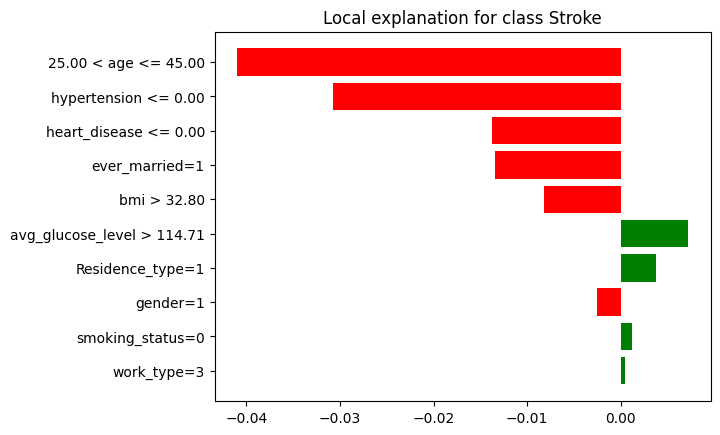

In [37]:
print("Explaining a Stroke Case (if available):")
stroke_indices = np.where(y_test == 1)[0]
explain_index(stroke_indices[0])

Explaining a No-Stroke Case:

--- Explaining instance 0 from Test Set ---
True Class: No Stroke
Prediction Probabilities: No Stroke: 1.0000, Stroke: 0.0000
Feature contributions to 'Stroke' class (LIME):
  25.00 < age <= 45.00                     : -0.0387
  hypertension <= 0.00                     : -0.0320
  ever_married=0                           : 0.0125
  heart_disease <= 0.00                    : -0.0084
  bmi <= 23.80                             : -0.0070
  gender=1                                 : -0.0063
  Residence_type=0                         : -0.0047
  avg_glucose_level <= 77.19               : -0.0039
  work_type=3                              : -0.0006
  smoking_status=0                         : -0.0003


/home/tim/Projects/AML/.venv/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
/home/tim/Projects/AML/.venv/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


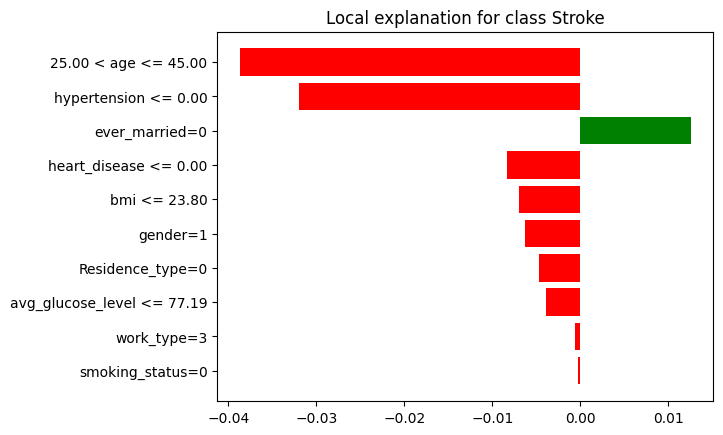

In [38]:
print("Explaining a No-Stroke Case:")
no_stroke_indices = np.where(y_test == 0)[0]
explain_index(no_stroke_indices[0])